In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge

In [2]:
# Import data from file
df = pd.read_csv('data/student_data.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
# Creating Independent and Dependent features
X = df.drop('math_score', axis=1)
y = df['math_score']

In [5]:
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['category', 'str']).columns.tolist()

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, categorical_features),
        ("StandardScaler", numeric_transformer, numeric_features),
    ]
)

In [6]:
X = preprocessor.fit_transform(X)

In [7]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
def evaluate_model(true, pred):
    MAE = skl.metrics.mean_absolute_error(true, pred)
    MSE = skl.metrics.mean_squared_error(true, pred)
    RMSE = skl.metrics.root_mean_squared_error(true, pred)
    R2 = skl.metrics.r2_score(true, pred)
    return MAE, MSE, RMSE, R2

In [9]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models = {
    "LinearRegression": skl.linear_model.LinearRegression(),
    "Ridge": skl.linear_model.Ridge(),
    "Lasso": skl.linear_model.Lasso(),
    "KNN": skl.neighbors.KNeighborsRegressor(),
    "SVR": skl.svm.SVR(),
    "DecisionTree": skl.tree.DecisionTreeRegressor(),
    "RandomForest": skl.ensemble.RandomForestRegressor(),
    "AdaBoost": skl.ensemble.AdaBoostRegressor(),
    "GradientBoost": skl.ensemble.GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(),
}

In [10]:
model_dict = {}
r2_dict = {}
mae_dict = {}
mse_dict = {}
rmse_dict = {}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    name = list(models.keys())[i]

    #make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluating model on train and test dataset
    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_dict.update({name: model})
    print(f"{name} :")
    print('Model Train set')
    print(f"R² score: {train_r2}")
    print(f"MAE: {train_mae}")
    print(f"MSE: {train_mse}")
    print(f"RMSE: {train_rmse}")
    print()
    print('Model Test set')
    print(f"R2 score: {test_r2}")
    print(f"MAE: {test_mae}")
    print(f"MSE: {test_mse}")
    print(f"RMSE: {test_rmse}")
    print('———————————————————————————————————')

    r2_dict.update({name: test_r2})
    mae_dict.update({name: test_mae})
    mse_dict.update({name: test_mse})
    rmse_dict.update({name: test_rmse})

LinearRegression :
Model Train set
R² score: 0.8743172040139593
MAE: 4.266711846071957
MSE: 28.33487038064859
RMSE: 5.323050852720514

Model Test set
R2 score: 0.8804332983749565
MAE: 4.21476314247485
MSE: 29.095169866715487
RMSE: 5.393993869732843
———————————————————————————————————
Ridge :
Model Train set
R² score: 0.8743042615212909
MAE: 4.264987823725981
MSE: 28.33778823308244
RMSE: 5.323324922741654

Model Test set
R2 score: 0.8805931485028737
MAE: 4.211100688014261
MSE: 29.056272192348324
RMSE: 5.390387016935642
———————————————————————————————————
Lasso :
Model Train set
R² score: 0.8071462015863455
MAE: 5.206302661246528
MSE: 43.47840400585581
RMSE: 6.593815587795568

Model Test set
R2 score: 0.8253197323627852
MAE: 5.157881810347764
MSE: 42.50641683841164
RMSE: 6.519694535667422
———————————————————————————————————
KNN :
Model Train set
R² score: 0.8554978341651085
MAE: 4.516749999999999
MSE: 32.57765
RMSE: 5.707683417990174

Model Test set
R2 score: 0.7838129945787431
MAE: 5.62

In [11]:
pd.DataFrame(list(zip(model_dict.keys(), r2_dict.values(), mae_dict.values(), mse_dict.values(), rmse_dict.values())),
             columns=['Model', 'R2', 'MAE', 'MSE', 'RMSE']).sort_values(by=['R2'],
                                                                        ascending=False)

,Model,R2,MAE,MSE,RMSE
1,Ridge,0.880593,4.211101,29.056272,5.390387
0,LinearRegression,0.880433,4.214763,29.095170,5.393994
8,GradientBoost,0.872487,4.310051,31.028711,5.570342
6,RandomForest,0.852902,4.636108,35.794522,5.982852
10,CatBoost,0.851632,4.612532,36.103658,6.008632
7,AdaBoost,0.837683,4.823506,39.497959,6.284740
9,XGBoost,0.827797,5.057731,41.903706,6.473307
2,Lasso,0.825320,5.157882,42.506417,6.519695
3,KNN,0.783813,5.621000,52.606600,7.253041
4,SVR,0.728600,5.401539,66.042005,8.126623


In [21]:
# Choosing Ridge Regression model from the above stats
ridge = skl.linear_model.Ridge(fit_intercept=True)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
score = skl.metrics.r2_score(y_test, y_pred)
print(f'R2 score of model: ',score)

R2 score of model:  0.8805931485028737


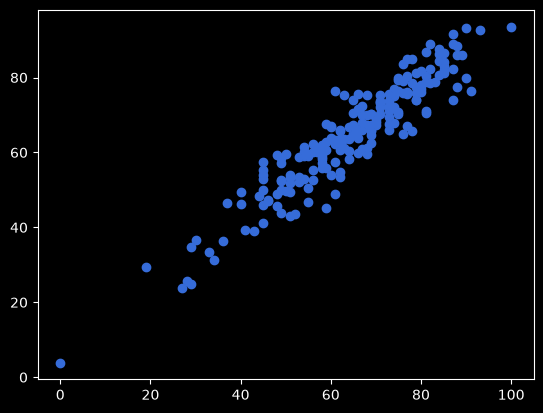

In [13]:
# Plot y_pred and y_test
plt.scatter(y_test, y_pred)

<Axes: xlabel='math_score'>

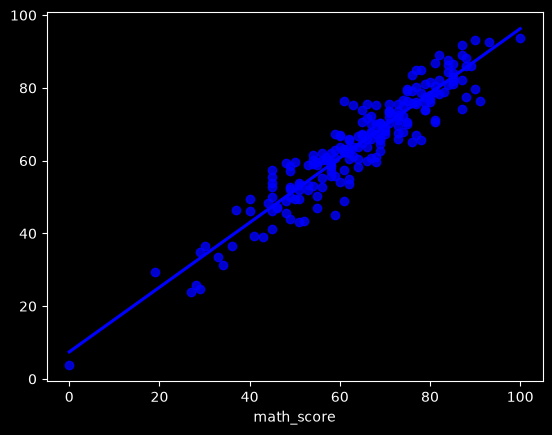

In [14]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='blue')

In [15]:
pred_df = pd.DataFrame({'Actual Value': y_test, "Predicted Value": y_pred, 'Difference': y_test - y_pred})

In [16]:
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.398705,14.601295
737,53,58.842469,-5.842469
740,80,76.992129,3.007871
660,74,76.805898,-2.805898
411,84,87.615387,-3.615387
...,...,...,...
408,52,43.492293,8.507707
332,62,62.170763,-0.170763
208,74,67.910325,6.089675
613,65,67.061504,-2.061504
